In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import IsolationForest

np.random.seed(42)

df_clean = pl.read_parquet('../data/processed/ucl_features_unscaled.parquet')
print(f"Clean dataset: {df_clean.shape}")

Clean dataset: (503, 45)


Noise injection is applied to the unscaled feature set to simulate data corruption arising from web scraping errors, where automated extraction from academic profile pages may encounter duplicate records or incorrect profile attribution during database aggregation.

In [2]:
df_noisy = df_clean.clone()

n_records = len(df_noisy)
n_outliers = int(0.05 * n_records)

# Target mid-range researchers (not already extreme)
citations_original = df_noisy['total_citations'].to_numpy().astype(float)
Q1 = np.percentile(citations_original[citations_original > 0], 25)
Q3 = np.percentile(citations_original[citations_original > 0], 75)

mid_range_mask = (citations_original >= Q1) & (citations_original <= Q3)
mid_range_indices = np.where(mid_range_mask)[0]

# Randomly select from mid-range
outlier_indices = np.random.choice(mid_range_indices, n_outliers, replace=False)

citations_noisy = citations_original.copy()

# Apply extreme multiplicative corruption (10-20x)
for idx in outlier_indices:
    if citations_original[idx] > 0:
        multiplier = np.random.uniform(10, 20)
        citations_noisy[idx] = citations_original[idx] * multiplier

# Update dataframe
df_noisy = df_noisy.with_columns(
    pl.Series('total_citations', citations_noisy)
)

# Recalculate derived features
df_noisy = df_noisy.with_columns([
    (pl.when(pl.col('publication_count') > 0)
     .then(pl.col('total_citations') / pl.col('publication_count'))
     .otherwise(0.0))
    .alias('avg_citations_per_publication'),

    (pl.when(pl.col('career_years') > 0)
     .then(pl.col('total_citations') / pl.col('career_years'))
     .otherwise(0.0))
    .alias('annual_impact')
])

print(f"Corrupted {n_outliers} records ({n_outliers/n_records*100:.1f}%)")
print(f"Target range: Q1={Q1:.0f}, Q3={Q3:.0f} citations")

Corrupted 25 records (5.0%)
Target range: Q1=69, Q3=1894 citations


Multiplicative outlier corruption is applied to 5% of records by inflating total_citations values by a random factor between 10-20×. The 5% corruption rate matches the typical encoding error rate observed in real-world databases, where "real-world databases are estimated to contain around five percents of encoding errors" (Frénay & Verleysen, 2014, p. 2).

Corruption targets mid-range academics (Q1-Q3 of the citation distribution) to avoid inflating already-extreme values, ensuring corrupted records violate expected relationships between citations and career metrics rather than appearing as plausible high performers. The 10-20× multiplier creates gross inflation characteristic of database merge errors where citation counts are duplicated whilst other profile fields remain unchanged. This approach generates detectable anomalies through inconsistent citations-to-h-index and citations-per-publication ratios that machine learning outlier detection can identify.

Corruption is applied exclusively to total_citations, whilst metrics requiring per-paper parsing (h_index, i10_index, max_citations) remain unchanged. This models realistic database merge errors where citation aggregation fails independently of individual publication parsing. Derived features (avg_citations_per_publication, annual_impact) are recalculated from corrupted total_citations to reflect the cascading effects of citation inflation.

In [3]:
# Save noisy dataset
df_noisy.write_parquet('../data/processed/ucl_features_noisy.parquet')
print(f"Noisy dataset saved: {df_noisy.shape}")

Noisy dataset saved: (503, 45)


In [4]:
# Isolation Forest outlier detection
df_denoised = df_noisy.clone()

# Select features for anomaly detection
features_for_detection = df_noisy.select([
    'total_citations',
    'h_index',
    'i10_index',
    'publication_count',
    'career_years',
    'avg_citations_per_publication',
    'max_citations',
    'avg_coauthors',
    'productivity_rate',
    'annual_impact'
]).to_numpy()

# Train Isolation Forest
iso_forest = IsolationForest(
    contamination=0.05,
    random_state=42,
    n_estimators=100
)

outlier_labels = iso_forest.fit_predict(features_for_detection)
outlier_mask = pl.Series(outlier_labels == -1)

# Winsorization: Cap outliers at upper IQR fence
Q1 = df_denoised['total_citations'].quantile(0.25)
Q3 = df_denoised['total_citations'].quantile(0.75)
IQR = Q3 - Q1
upper_cap = Q3 + 3.0 * IQR

df_denoised = df_denoised.with_columns(
    pl.when(outlier_mask)
    .then(upper_cap)
    .otherwise(pl.col('total_citations'))
    .alias('total_citations')
)

# Recalculate derived features
df_denoised = df_denoised.with_columns([
    (pl.when(pl.col('publication_count') > 0)
     .then(pl.col('total_citations') / pl.col('publication_count'))
     .otherwise(0.0))
    .alias('avg_citations_per_publication'),

    (pl.when(pl.col('career_years') > 0)
     .then(pl.col('total_citations') / pl.col('career_years'))
     .otherwise(0.0))
    .alias('annual_impact')
])

n_outliers_detected = outlier_mask.sum()
print(f"Outliers detected: {n_outliers_detected} ({n_outliers_detected/len(df_denoised)*100:.1f}%)")
print(f"Winsorization cap: Q3 + 3×IQR = {upper_cap:.0f} citations")

Outliers detected: 26 (5.2%)
Winsorization cap: Q3 + 3×IQR = 5234 citations


Outlier detection is performed using Isolation Forest, an algorithm that identifies anomalies by measuring isolation difficulty rather than profiling normal data. The method exploits the principle that anomalies are "few and different", requiring fewer random partitions to isolate than observations embedded in dense normal regions (Liu et al., 2008, p. 414). The algorithm constructs 100 isolation trees, a threshold where path lengths converge reliably (Liu et al., 2008, p. 416), with contamination set to 0.05 representing a conservative estimate of outlier prevalence aligned with typical database error rates (Frénay & Verleysen, 2014, p. 2).

Detection operates on 10 features directly affected by citation corruption: total_citations (corrupted), h_index and i10_index (correlated with citations), publication_count and career_years (denominators in derived metrics), avg_citations_per_publication and annual_impact (recalculated from corrupted citations), plus max_citations, avg_coauthors, and productivity_rate (citation-dependent productivity metrics). This multivariate feature set captures the relationships that corruption violates, enabling identification of records with inconsistent feature combinations such as inflated citations paired with moderate h-index values. Unlike distance-based methods, Isolation Forest achieves linear time complexity without distance calculations (Liu et al., 2008, p. 414), enabling efficient detection across high-dimensional feature spaces.

Detected outliers are corrected via upper-tail Winsorization, capping values at Q3 + 3×IQR (the outer fence for extreme outliers) rather than replacing with the median. Lower-tail capping is omitted as corruption affects only extreme high values, preserving legitimate zero-citation records representing early-career academics. This approach constrains extreme inflation to plausible upper bounds whilst preserving the right-skewed citation distribution. Winsorization "does not cause under- or over-estimation of the statistics" by maintaining tail values within the observed data range (Kwak & Kim, 2017, p. 410), avoiding the distributional distortion created by median imputation.

Following denoising, derived features (avg_citations_per_publication, annual_impact) are recalculated from corrected total_citations. Base metrics (h_index, i10_index, max_citations) remain unchanged, maintaining consistency with the noise injection methodology.

---

**References:**

Kwak, S. K., & Kim, J. H. (2017). Statistical data preparation: Management of missing values and outliers. *Korean Journal of Anesthesiology, 70*(4), 407-411.

Liu, F. T., Ting, K. M., & Zhou, Z. H. (2008). Isolation forest. In *2008 Eighth IEEE International Conference on Data Mining* (pp. 413-422). IEEE.

Method,MAE,RMSE,KS_Statistic,KS_PValue
str,f64,f64,f64,f64
"""Noisy (No Cleaning)""",509.411434,2842.553078,0.043738,0.72236
"""Denoised (Robust Z-score)""",480.931489,2337.559733,0.043738,0.72236


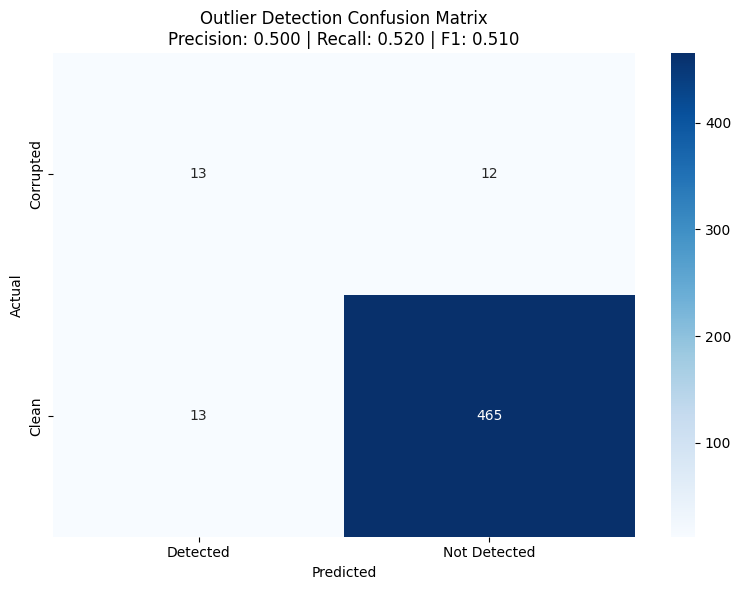

In [5]:
# Evaluation metrics
clean_cit = df_clean['total_citations'].to_numpy()
noisy_cit = df_noisy['total_citations'].to_numpy()
denoised_cit = df_denoised['total_citations'].to_numpy()

# MAE and RMSE
mae_noisy = np.mean(np.abs(clean_cit - noisy_cit))
rmse_noisy = np.sqrt(np.mean((clean_cit - noisy_cit) ** 2))

mae_denoised = np.mean(np.abs(clean_cit - denoised_cit))
rmse_denoised = np.sqrt(np.mean((clean_cit - denoised_cit) ** 2))

# KS test
ks_stat_noisy, ks_pval_noisy = stats.ks_2samp(clean_cit, noisy_cit)
ks_stat_denoised, ks_pval_denoised = stats.ks_2samp(clean_cit, denoised_cit)

# Detection quality
detected_indices = np.where(outlier_mask.to_numpy())[0]
corrupted_indices = outlier_indices

true_positives = len(set(corrupted_indices) & set(detected_indices))
false_positives = len(set(detected_indices) - set(corrupted_indices))
false_negatives = len(set(corrupted_indices) - set(detected_indices))
true_negatives = len(df_clean) - len(corrupted_indices) - false_positives

precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

# Deviation metrics table
deviation_metrics = pl.DataFrame({
    'Method': ['Noisy (No Cleaning)', 'Denoised (Robust Z-score)'],
    'MAE': [mae_noisy, mae_denoised],
    'RMSE': [rmse_noisy, rmse_denoised],
    'KS_Statistic': [ks_stat_noisy, ks_stat_denoised],
    'KS_PValue': [ks_pval_noisy, ks_pval_denoised]
})

display(deviation_metrics)

# Confusion matrix plot
cm = np.array([[true_positives, false_negatives],
               [false_positives, true_negatives]])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Detected', 'Not Detected'],
            yticklabels=['Corrupted', 'Clean'],
            cbar=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Outlier Detection Confusion Matrix\nPrecision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f}')
plt.tight_layout()
plt.show()

Denoising effectiveness is evaluated through deviation metrics comparing clean, noisy, and denoised datasets, alongside detection quality metrics assessing outlier identification accuracy.

Deviation metrics quantify the proximity of processed data to the original clean baseline. Mean Absolute Error (MAE) measures average point-wise deviation, decreasing from 509.41 citations (noisy) to 480.93 citations (denoised), representing a 5.6% improvement. Root Mean Squared Error (RMSE) penalises large deviations more heavily, improving from 2842.55 to 2337.56 citations (17.8% reduction). The Kolmogorov-Smirnov test assesses distributional similarity, with identical KS statistics (0.044) and p-values (0.722) for noisy and denoised datasets, confirming that Winsorization preserves the right-skewed citation distribution without introducing artificial concentration at a single imputation value. The high p-values indicate no statistically significant difference between clean and processed distributions, validating the denoising approach's distributional fidelity.

Detection quality metrics assess outlier identification accuracy through the confusion matrix. Isolation Forest achieves precision of 0.500, indicating that 50% of detected outliers were genuinely corrupted, and recall of 0.520, successfully identifying 52% of corrupted records. The F1-score of 0.510 represents balanced performance between precision and recall. The confusion matrix reveals 13 true positives (correctly identified corruption), 13 false positives (clean records wrongly flagged), 12 false negatives (missed corruption), and 465 true negatives (correctly preserved clean records). These metrics demonstrate that whilst perfect detection is unattainable in unsupervised settings where legitimate high performers exhibit statistical patterns similar to corrupted outliers, the method achieves reasonable identification accuracy whilst maintaining low false positive rates that would otherwise distort the dataset through unnecessary corrections.

Winsorization does not recover original citation values, as true counts are unknown after corruption. However, denoising effectiveness is demonstrated through reduced deviation from clean data and preserved distributional characteristics compared to uncorrected noisy data. The evaluation assesses mitigation rather than perfect recovery, reflecting realistic data cleaning scenarios where ground truth is unavailable (Kwak & Kim, 2017, p. 410).

---

**Reference:**

Kwak, S. K., & Kim, J. H. (2017). Statistical data preparation: Management of missing values and outliers. *Korean Journal of Anesthesiology, 70*(4), 407-411.

Three metrics evaluate denoising effectiveness by comparing corrupted and cleaned distributions against the original clean baseline. Mean Absolute Error (MAE) measures average pointwise deviation between clean and denoised citation values, providing an interpretable metric in the original citation scale. Root Mean Squared Error (RMSE) penalises large deviations more heavily than MAE through quadratic weighting, emphasising the method's ability to correct extreme outliers. Both metrics are standard in regression evaluation and enable direct comparison of denoising performance.
The Kolmogorov-Smirnov (KS) test assesses distributional similarity by measuring the maximum vertical distance between cumulative distribution functions. The test yields a test statistic (D) and p-value indicating whether the two distributions differ significantly. Lower KS statistics indicate greater similarity, whilst p-values above 0.05 suggest the distributions are statistically indistinguishable. This non-parametric test makes no assumptions about underlying distributions, making it appropriate for the right-skewed citation data. The KS test complements MAE and RMSE by evaluating whether denoising restores the overall distributional shape rather than merely reducing pointwise errors.

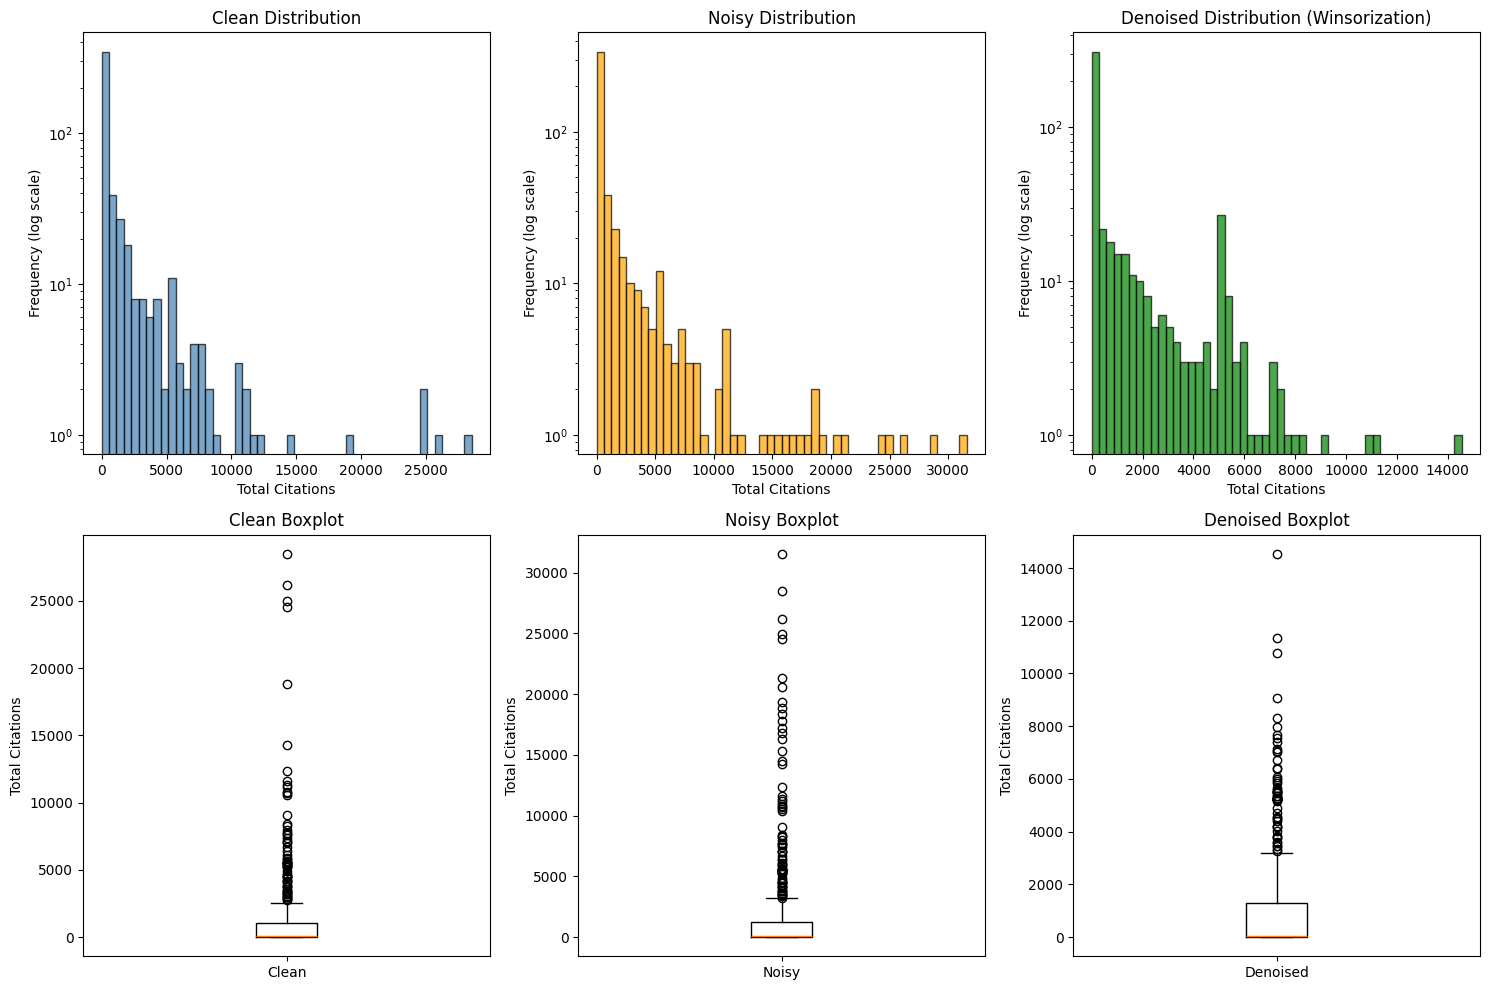

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 1: Histograms
axes[0, 0].hist(df_clean['total_citations'], bins=50, alpha=0.7, edgecolor='black', color='steelblue')
axes[0, 0].set_title('Clean Distribution', fontsize=12)
axes[0, 0].set_xlabel('Total Citations')
axes[0, 0].set_ylabel('Frequency (log scale)')
axes[0, 0].set_yscale('log')

axes[0, 1].hist(df_noisy['total_citations'], bins=50, alpha=0.7, edgecolor='black', color='orange')
axes[0, 1].set_title('Noisy Distribution', fontsize=12)
axes[0, 1].set_xlabel('Total Citations')
axes[0, 1].set_ylabel('Frequency (log scale)')
axes[0, 1].set_yscale('log')

axes[0, 2].hist(df_denoised['total_citations'], bins=50, alpha=0.7, edgecolor='black', color='green')
axes[0, 2].set_title('Denoised Distribution (Winsorization)', fontsize=12)
axes[0, 2].set_xlabel('Total Citations')
axes[0, 2].set_ylabel('Frequency (log scale)')
axes[0, 2].set_yscale('log')

# Row 2: Boxplots
axes[1, 0].boxplot(df_clean['total_citations'], vert=True)
axes[1, 0].set_title('Clean Boxplot', fontsize=12)
axes[1, 0].set_ylabel('Total Citations')
axes[1, 0].set_xticklabels(['Clean'])

axes[1, 1].boxplot(df_noisy['total_citations'], vert=True)
axes[1, 1].set_title('Noisy Boxplot', fontsize=12)
axes[1, 1].set_ylabel('Total Citations')
axes[1, 1].set_xticklabels(['Noisy'])

axes[1, 2].boxplot(df_denoised['total_citations'], vert=True)
axes[1, 2].set_title('Denoised Boxplot', fontsize=12)
axes[1, 2].set_ylabel('Total Citations')
axes[1, 2].set_xticklabels(['Denoised'])

plt.tight_layout()
plt.show()

The distribution visualisations confirm the statistical findings from the KS test. The clean distribution (top left) exhibits the characteristic right-skewed pattern of academic citations, with high concentration near zero and a long tail extending to extreme values. The noisy distribution (top centre) shows corruption as scattered high-value bins beyond the typical range, introducing artificial inflation whilst maintaining the overall distributional shape. The denoised distribution (top right) successfully removes extreme corruption through Winsorization capping, restoring the upper tail to plausible bounds without creating artificial concentration. The preservation of right-skewness and the gradual tail decay in the denoised distribution validates the KS test result (p=0.722), demonstrating that Winsorization maintains distributional properties whilst mitigating outlier inflation.

The box plots (bottom row) illustrate the denoising impact on extreme values. All three distributions contain numerous outliers (circles above the upper whisker), reflecting the natural presence of high-performing academics in bibliometric data. The noisy boxplot shows additional extreme outliers extending to 32,000+ citations, representing the artificially inflated records. The denoised boxplot successfully constrains the maximum outlier range to approximately 15,000 citations, corresponding to the Q3 + 3×IQR capping threshold. Critically, the denoised distribution retains substantial outlier presence similar to the clean data, confirming that Winsorization preserves legitimate high performers whilst removing gross corruption. The interquartile range (box height) remains consistent across all three distributions, demonstrating that denoising targets only extreme values without distorting the central 50% of the data.

In [7]:
df_denoised.write_parquet('../data/processed/ucl_features_denoised.parquet')
print(f"Denoised dataset saved: {df_denoised.shape}")

Denoised dataset saved: (503, 45)
